# American Sign Language (ASL) Recognition using PCA
## Project Overview
This project aims to build a robust **Hand Gesture Recognition** system using **Principal Component Analysis (PCA)** for dimensionality reduction and feature extraction. The system is designed to classify 29 categories of ASL (A-Z + Space, Delete, Nothing).

### Objectives:
1. **Data Preprocessing:** Standardizing image sizes, noise reduction, and grayscale conversion.
2. **Augmentation:** Enhancing the dataset to handle lighting and rotation variances.
3. **Dimensionality Reduction:** Utilizing PCA to capture the most significant "EigenHands".
4. **Real-time Integration:** Preparing the pipeline for Live Inference via Webcam.

### Dataset Insights:
- **Total Images:** 87,000.
- **Resolution:** 200x200 Pixels.
- **Classes:** 29 (26 Letters + 3 Special Tokens).
- **Environment:** Kaggle Notebook environment.

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
base_path = r"D:\Users\DEPI\pyton\Session3\asl-alphabet"
print(os.listdir(base_path))

['asl_alphabet_test', 'asl_alphabet_train']


In [7]:
TRAIN_DIR = r'D:\Users\DEPI\pyton\Session3\asl-alphabet\asl_alphabet_train\asl_alphabet_train'

IMG_SIZE = (64, 64) # Optimal for PCA efficiency
CLASSES = sorted(os.listdir(TRAIN_DIR))
print(f"Total Classes: {len(CLASSES)}")

Total Classes: 29


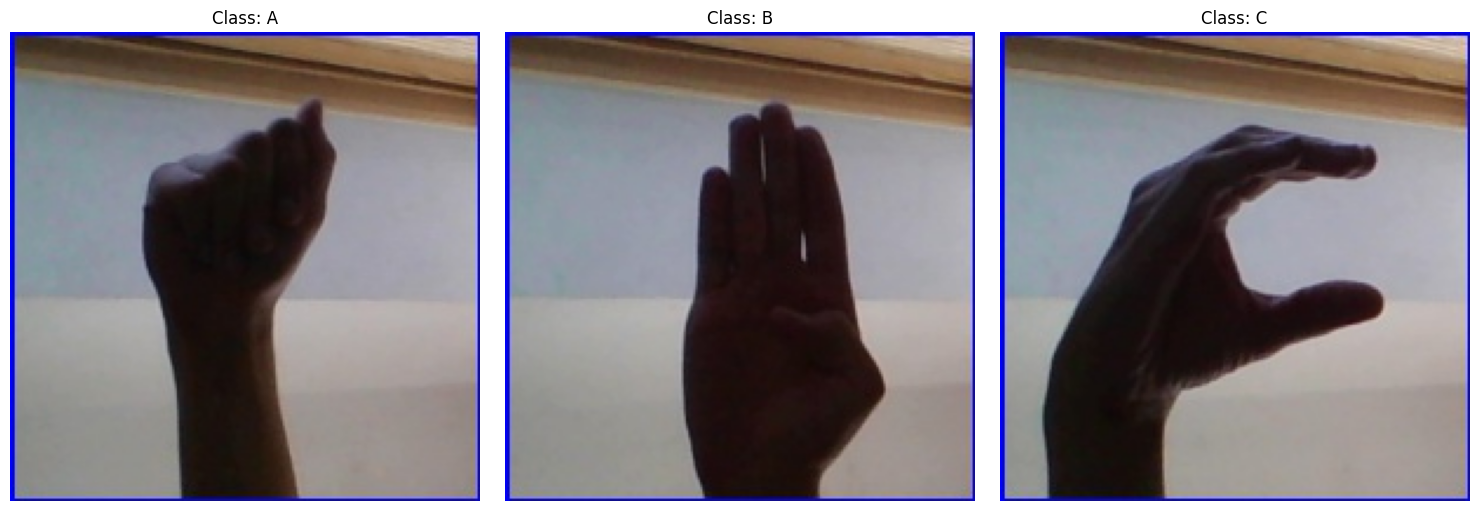

In [8]:
def load_sample_images(data_dir, classes, num_samples=3):
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes[:3]): # Displaying first 3 classes as sample
        img_path = glob(os.path.join(data_dir, cls, "*.jpg"))[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"Class: {cls}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

load_sample_images(TRAIN_DIR, CLASSES)

## Data preprocessing

In [9]:
def professional_preprocess_pipeline(image, target_size=IMG_SIZE):
    # 1. Resize image to the targeted size for consistency
    img_resized = cv2.resize(image, target_size)
    
    # 2. Skin Segmentation using YCrCb color space
    img_ycrcb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_ycrcb, lower_skin, upper_skin)
    
    # 3. Morphology to clean the mask noise
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    # 4. Feature Extraction using Canny Edges
    masked_img = cv2.bitwise_and(img_resized, img_resized, mask=mask)
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    
    # 5. Normalization for PCA processing
    normalized_edges = edges / 255.0
    
    return normalized_edges, mask

print("Preprocessing Pipeline Defined.")

Preprocessing Pipeline Defined.


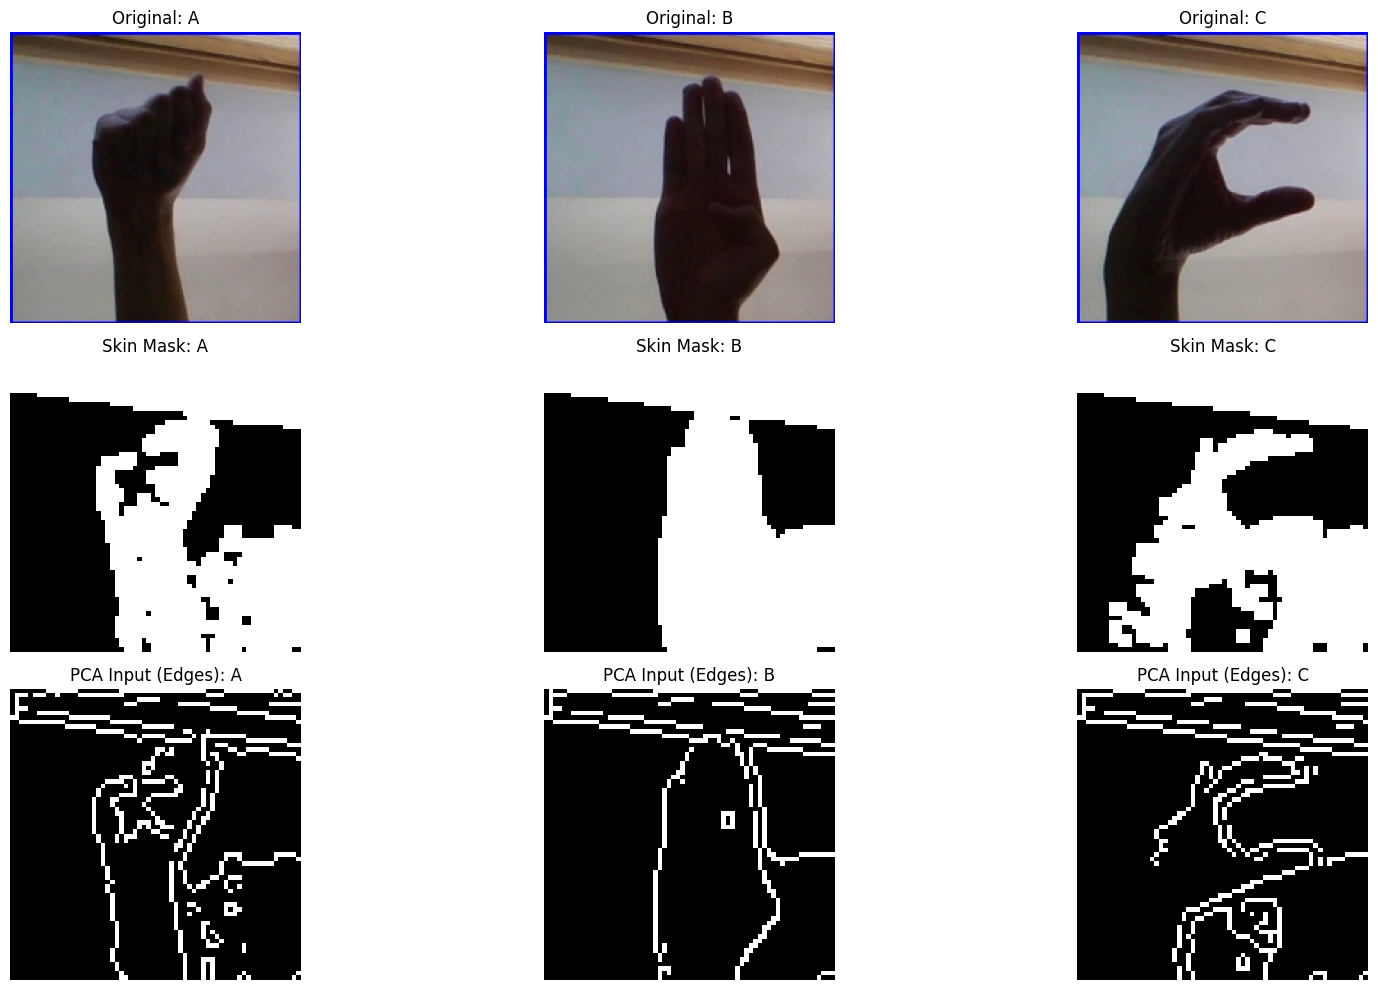

In [10]:
def show_pipeline_steps(num_classes=3):
    plt.figure(figsize=(18, 10))
    for i in range(num_classes):
        cls = CLASSES[i]
        path = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[0]
        original = cv2.imread(path)
        processed, mask = professional_preprocess_pipeline(original)
        
        # Visualize the 3 stages: Original -> Mask -> Edges
        plt.subplot(3, num_classes, i + 1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {cls}")
        plt.axis('off')
        
        plt.subplot(3, num_classes, i + 1 + num_classes)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Skin Mask: {cls}")
        plt.axis('off')
        
        plt.subplot(3, num_classes, i + 1 + 2*num_classes)
        plt.imshow(processed, cmap='gray')
        plt.title(f"PCA Input (Edges): {cls}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_pipeline_steps()

In [11]:
# Data Augmentation & Generators
print("Processing images using Augmentation Strategy...")

# Re-initializing augmenter with critical rescale and validation split
augmenter = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    fill_mode='constant',
    cval=0
)

# Streaming Training Data
train_data = augmenter.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224), # Targeted for MobileNetV2 input
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Streaming Validation Data
val_data = augmenter.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Total Training Samples: {train_data.samples}")
print(f"Total Validation Samples: {val_data.samples}")

Processing images using Augmentation Strategy...
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Total Training Samples: 69600
Total Validation Samples: 17400


In [12]:
# Mass Processing & Structural Augmentation for PCA

# Initialize data containers
X = []
y = []

# Set samples per class: 200 original + 200 augmented = 400 total samples per class
# This is memory-safe for Kaggle and mathematically sufficient for PCA
SAMPLES_PER_CLASS = 200 

print(f"Processing {SAMPLES_PER_CLASS} base images + Augmentation per class...")

for label, cls in enumerate(CLASSES):
    # Fetch image paths for the current class
    img_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[:SAMPLES_PER_CLASS]
    
    for path in img_paths:
        # 1. Execute Professional Pipeline (Skin Masking & Edge Detection)
        raw_img = cv2.imread(path)
        # Ensure image is not None
        if raw_img is None: continue
        
        processed_img, _ = professional_preprocess_pipeline(raw_img)
        
        # 2. Append original processed image (Flattened for PCA)
        X.append(processed_img.flatten())
        y.append(label)
        
        # 3. Apply Augmentation to the Edges
        # Reshape to (H, W, 1) for the augmenter
        img_reshaped = processed_img.reshape(IMG_SIZE[0], IMG_SIZE[1], 1)
        
        # Generate a random transformation
        augmented_img = augmenter.random_transform(img_reshaped)
        
        # Append augmented version
        X.append(augmented_img.flatten())
        y.append(label)

# Convert to Numpy arrays
X = np.array(X, dtype='float32')
y = np.array(y)

print("---" * 10)
print(f"Preprocessing & Augmentation Complete!")
print(f"Final Dataset Shape for PCA: {X.shape}") 
print(f"Total Unique Classes Covered: {len(np.unique(y))}")

Processing 200 base images + Augmentation per class...
------------------------------
Preprocessing & Augmentation Complete!
Final Dataset Shape for PCA: (11600, 4096)
Total Unique Classes Covered: 29


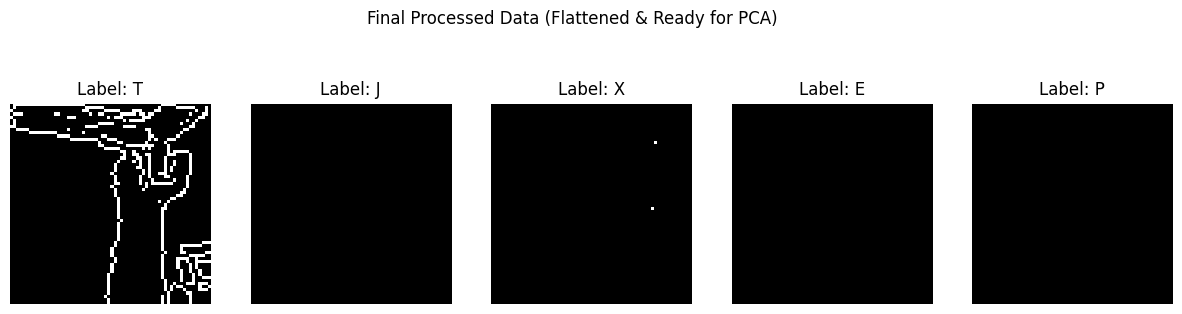

In [13]:
# Final check to see the data exactly as PCA will see it
plt.figure(figsize=(15, 4))
indices = np.random.choice(len(X), 5)
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[idx].reshape(IMG_SIZE), cmap='gray')
    plt.title(f"Label: {CLASSES[y[idx]]}")
    plt.axis('off')
plt.suptitle("Final Processed Data (Flattened & Ready for PCA)")
plt.show()

In [14]:
# Live Inference Pipeline & Temporal Smoothing logic

import time
from collections import Counter

def prepare_live_frame(frame, target_size=IMG_SIZE):
    """
    Standardizes incoming webcam frames to match the PCA training format.
    """
    # Use the same professional pipeline we used for training
    processed_frame, _ = professional_preprocess_pipeline(frame, target_size)
    
    # Return flattened for PCA prediction
    return processed_frame.flatten().reshape(1, -1)

class TemporalSmoother:
    """
    Prevents prediction flickering by using a rolling buffer (Voting Mechanism).
    """
    def __init__(self, buffer_size=5):
        self.buffer = []
        self.buffer_size = buffer_size

    def smooth_predict(self, new_prediction):
        self.buffer.append(new_prediction)
        if len(self.buffer) > self.buffer_size:
            self.buffer.pop(0)
        
        # Return the most frequent prediction in the buffer
        most_common = Counter(self.buffer).most_common(1)
        return most_common[0][0]

# Initialize the smoother for later use in the Live script
smoother = TemporalSmoother(buffer_size=7)

print("Live Inference Pipeline & Temporal Smoother are ready.")

Live Inference Pipeline & Temporal Smoother are ready.


## Applying PCA: The "Compression" Step

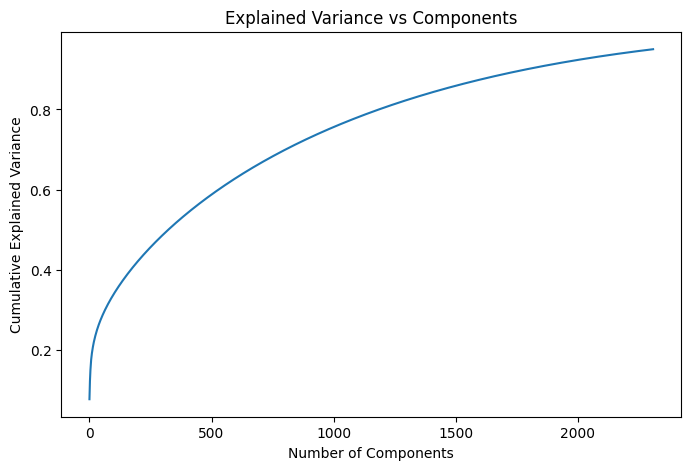

In [15]:
# Feature scaling followed by PCA dimensionality reduction
scalar = StandardScaler()
x_scaled = scalar.fit_transform(X)

# Retain 95% of the variance
pca = PCA(n_components=0.95) 
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Explained Variance vs Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [16]:
# HOG Feature Extraction (Optional - for reference)
from skimage.feature import hog
# Select a sample image from X and reshape it
sample_img = X[0].reshape(IMG_SIZE)
features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm='L2-Hys'
)

In [17]:
print(f"HOG Feature Vector Shape: {features.shape}")

HOG Feature Vector Shape: (1764,)


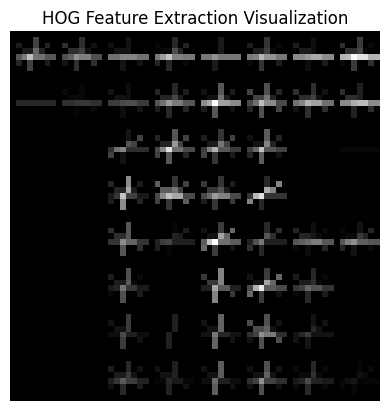

In [18]:
# Visualize HOG result
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Feature Extraction Visualization")
plt.axis('off')
plt.show()

## Train/Test Split

In [19]:
# Splitting the PCA-transformed data into Training and Testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_pca, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Maintains the same class distribution
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (9280, 2310)
Testing set shape: (2320, 2310)


## Train ML Models

In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

# Loading pre-trained MobileNetV2 without the top layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freezing weights

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(), 
    Dropout(0.4),
    Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,397 (9.90 MB)

 Trainable params: 335,901 (1.28 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

print("Starting Training...")
history = model.fit(
    train_data,
    steps_per_epoch=200, # Training on 200 batches per epoch
    validation_data=val_data,
    validation_steps=50,
    epochs=10, 
    callbacks=[early_stop, reduce_lr]
)

Starting Training...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.6255 - loss: 1.3568 - val_accuracy: 0.8313 - val_loss: 0.7020 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8378 - loss: 0.5603 - val_accuracy: 0.8712 - val_loss: 0.4900 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.8642 - loss: 0.4525 - val_accuracy: 0.7994 - val_loss: 0.6810 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8884 - loss: 0.3690 - val_accuracy: 0.8406 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8963 - loss: 0.3317 - val_accuracy: 0.9038 - val_loss: 0.3259 - learning_rate: 2.0000e-04
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9091 - loss: 0.2947 - val_accuracy: 0.8938 - val_loss: 0.3526 - learning_rate: 2.0000e-04
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


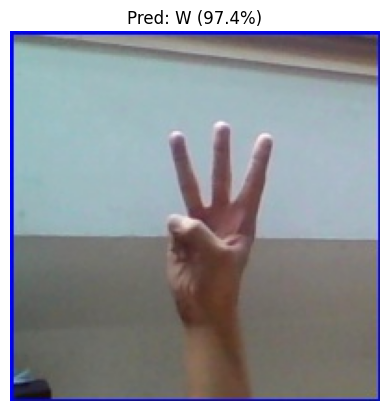

In [23]:
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_data.class_indices.keys())

def predict_and_show(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    input_img = cv2.resize(img_rgb, (224, 224))
    input_img = input_img / 255.0
    input_img = np.expand_dims(input_img, axis=0)

    pred = model.predict(input_img)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    label = f"Pred: {class_names[class_idx]} ({confidence*100:.1f}%)"

    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()

test_path = r'D:\Users\DEPI\pyton\Session3\asl-alphabet\asl_alphabet_train\asl_alphabet_train\W\W1000.jpg'
predict_and_show(test_path)

## 💾 Save Model & Artifacts

Run this once after training to persist the model, scaler, PCA, and class names to disk. After saving you can restart the kernel and jump straight to the **Load & Run GUI** section below.

In [24]:
import os, pickle
import joblib

SAVE_DIR = './asl_model_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Keras model
model.save(os.path.join(SAVE_DIR, 'mobilenetv2_asl.keras'))
print("✅ Model saved.")

# 2. StandardScaler  (fitted on the edge-feature matrix X)
joblib.dump(scalar, os.path.join(SAVE_DIR, 'scaler.joblib'))
print("✅ Scaler saved.")

# 3. PCA object
joblib.dump(pca, os.path.join(SAVE_DIR, 'pca.joblib'))
print("✅ PCA saved.")

# 4. Class names  (derived from train_data.class_indices)
class_names_save = list(train_data.class_indices.keys())
with open(os.path.join(SAVE_DIR, 'class_names.pkl'), 'wb') as f:
    pickle.dump(class_names_save, f)
print("✅ Class names saved.")

print(f"\nAll artifacts saved to: {os.path.abspath(SAVE_DIR)}/")


✅ Model saved.
✅ Scaler saved.
✅ PCA saved.
✅ Class names saved.

All artifacts saved to: d:\Users\DEPI\pyton\Session3\asl_model_artifacts/


## 🖐️ ASL Gesture Classifier — Interactive GUI

Run the cell below to launch a file-picker interface. Upload any hand-gesture image and the trained model will classify it instantly.

In [25]:
# Install / enable ipywidgets (safe to re-run)
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ipywidgets'], check=False)


CompletedProcess(args=['d:\\Users\\DEPI\\pyton\\Session3\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'ipywidgets'], returncode=0)

In [1]:
! pip install ipywidgets
! jupyter nbextension enable --py widgetsnbextension --sys-prefix


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


## 🚀 Load & Run GUI  *(standalone — no retraining needed)*

Start here after a kernel restart. Just set `SAVE_DIR` to wherever you saved the artifacts, then run this single cell to get the full classifier GUI.

In [ ]:
import io, base64, pickle
import numpy as np
import cv2
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from tensorflow.keras.models import load_model


# ── 1. Load artifacts ────────────────────────────────────────────────────────
SAVE_DIR = './asl_model_artifacts'   # ← change if you moved the folder

model       = load_model(f'{SAVE_DIR}/mobilenetv2_asl.keras')
scalar      = joblib.load(f'{SAVE_DIR}/scaler.joblib')
pca         = joblib.load(f'{SAVE_DIR}/pca.joblib')
IMG_SIZE    = (64, 64)

with open(f'{SAVE_DIR}/class_names.pkl', 'rb') as f:
    class_names = pickle.load(f)

print(f"✅ Loaded model  |  {len(class_names)} classes  |  PCA components: {pca.n_components_}")

# ── 2. Helpers ───────────────────────────────────────────────────────────────
def professional_preprocess_pipeline(image, target_size=IMG_SIZE):
    img_resized  = cv2.resize(image, target_size)
    img_ycrcb    = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)
    lower_skin   = np.array([0, 133, 77],  dtype=np.uint8)
    upper_skin   = np.array([255, 173, 127], dtype=np.uint8)
    mask         = cv2.inRange(img_ycrcb, lower_skin, upper_skin)
    kernel       = np.ones((3, 3), np.uint8)
    mask         = cv2.dilate(mask, kernel, iterations=1)
    masked_img   = cv2.bitwise_and(img_resized, img_resized, mask=mask)
    gray         = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    edges        = cv2.Canny(gray, 50, 150)
    return edges / 255.0, mask

def preprocess_for_mobilenet(img_array, target=(224, 224)):
    img = cv2.resize(img_array, target) / 255.0
    return np.expand_dims(img, axis=0)

def decode_image(file_bytes):
    arr = np.frombuffer(file_bytes, dtype=np.uint8)
    bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError('Could not decode image – make sure it is a valid JPG/PNG.')
    return bgr   # keep BGR; pipeline expects BGR

def predict_gesture(bgr_img):
    # MobileNetV2 branch (primary)
    rgb      = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    inp      = preprocess_for_mobilenet(rgb)
    preds    = model.predict(inp, verbose=0)[0]
    top5_idx = preds.argsort()[-5:][::-1]
    top5     = [(class_names[i], float(preds[i]) * 100) for i in top5_idx]
    return top5[0][0], top5[0][1], top5

def img_to_data_uri(bgr_img, max_px=300):
    h, w  = bgr_img.shape[:2]
    scale = min(1.0, max_px / max(h, w))
    if scale < 1.0:
        bgr_img = cv2.resize(bgr_img, (int(w * scale), int(h * scale)))
    _, buf = cv2.imencode('.jpg', bgr_img)
    b64    = base64.b64encode(buf).decode()
    return f'data:image/jpeg;base64,{b64}'

def make_bar(label, pct, is_top):
    color = '#4CAF50' if is_top else '#90CAF9'
    weight = 'bold' if is_top else 'normal'
    return (
        f'<div style="margin:4px 0">'
        f'<span style="display:inline-block;width:70px;font-weight:{weight};font-size:14px">{label}</span>'
        f'<div style="display:inline-block;background:#e0e0e0;border-radius:4px;width:200px;height:16px;vertical-align:middle">'
        f'<div style="background:{color};width:{pct:.1f}%;height:100%;border-radius:4px"></div></div>'
        f'<span style="margin-left:8px;font-size:13px">{pct:.1f}%</span>'
        f'</div>'
    )

# ── 3. Widgets ───────────────────────────────────────────────────────────────
title_html = widgets.HTML(
    '<h2 style="font-family:sans-serif;color:#1565C0;margin-bottom:4px">'
    '🖐️ ASL Hand Gesture Classifier</h2>'
    '<p style="font-family:sans-serif;color:#555;margin-top:0">'
    'Upload a hand-gesture image (JPG or PNG) to classify it into one of the '
    '29 ASL categories (A–Z + Space, Delete, Nothing).</p>'
)

upload_btn   = widgets.FileUpload(
    accept='.jpg,.jpeg,.png', multiple=False,
    description='📂 Choose Image',
    layout=widgets.Layout(width='200px', margin='8px 0')
)
classify_btn = widgets.Button(
    description='🔍 Classify', button_style='success',
    layout=widgets.Layout(width='140px', height='36px', margin='8px 4px')
)
clear_btn    = widgets.Button(
    description='🗑️ Clear', button_style='warning',
    layout=widgets.Layout(width='120px', height='36px', margin='8px 4px')
)
status_label = widgets.HTML('')
result_out   = widgets.Output()

# ── 4. Handlers ──────────────────────────────────────────────────────────────
def on_classify(b):
    with result_out:
        clear_output(wait=True)
        if not upload_btn.value:
            display(HTML('<p style="color:red;font-family:sans-serif">⚠️ Please upload an image first.</p>'))
            return
        uploaded   = upload_btn.value
        file_bytes = (list(uploaded.values())[0]['content']
                      if isinstance(uploaded, dict) else uploaded[0]['content'])
        status_label.value = '<p style="font-family:sans-serif;color:#555">⏳ Classifying…</p>'
        try:
            bgr_img            = decode_image(bytes(file_bytes))
            label, conf, top5  = predict_gesture(bgr_img)
            data_uri           = img_to_data_uri(bgr_img)
            bars_html          = ''.join(make_bar(lbl, pct, i == 0) for i, (lbl, pct) in enumerate(top5))
            display(HTML(f'''
            <div style="display:flex;gap:24px;align-items:flex-start;font-family:sans-serif">
              <div><img src="{data_uri}" style="border-radius:10px;box-shadow:0 2px 8px rgba(0,0,0,0.25)"></div>
              <div>
                <h3 style="color:#1565C0;margin:0 0 6px 0">Prediction: {label}</h3>
                <p style="margin:0 0 12px 0;color:#388E3C;font-size:15px">Confidence: <b>{conf:.1f}%</b></p>
                <p style="margin:0 0 6px 0;font-weight:bold;color:#555">Top-5 Predictions:</p>
                {bars_html}
              </div>
            </div>'''))
            status_label.value = ''
        except Exception as e:
            status_label.value = ''
            display(HTML(f'<p style="color:red;font-family:sans-serif">❌ Error: {e}</p>'))

def on_clear(b):
    with result_out:
        clear_output()
    status_label.value = ''
    upload_btn.value   = {}

classify_btn.on_click(on_classify)
clear_btn.on_click(on_clear)

# ── 5. Layout ────────────────────────────────────────────────────────────────
panel = widgets.VBox(
    [title_html, upload_btn, widgets.HBox([classify_btn, clear_btn]), status_label, result_out],
    layout=widgets.Layout(padding='16px', border='1px solid #BBDEFB',
                          border_radius='10px', width='620px')
)
display(panel)


✅ Loaded model  |  29 classes  |  PCA components: 2310
